In [1]:
# imports

# ASTRA imports
from cil.plugins.astra.operators import ProjectionOperator


In [2]:
path = '/home5/s5248582/Documents/Data/valnut/'

In [3]:
# remove some annoying warnings
import logging
logger = logging.getLogger('dxchange')
logger.setLevel(logging.ERROR)

In [4]:
import os
from cil.io import ZEISSDataReader, TIFFWriter
from cil.processors import TransmissionAbsorptionConverter, Slicer
from cil.recon import FDK
from cil.utilities.display import show2D, show_geometry
from cil.utilities.jupyter import islicer, link_islicer

In [5]:
filename = os.path.join(path, "valnut_2014-03-21_643_28/tomo-A/valnut_tomo-A.txrm")

data = ZEISSDataReader(file_name=filename).read()

In [6]:
type(data)

cil.framework.acquisition_data.AcquisitionData

In [7]:
print(data.geometry)

3D Cone-beam tomography
System configuration:
	Source position: [   0.        , -105.05081177,    0.        ]
	Rotation axis position: [0., 0., 0.]
	Rotation axis direction: [0., 0., 1.]
	Detector position: [ 0.        , 45.08757401,  0.        ]
	Detector direction x: [1., 0., 0.]
	Detector direction y: [0., 0., 1.]
Panel configuration:
	Number of pixels: [1024 1024]
	Pixel size: [0.0658543 0.0658543]
	Pixel origin: bottom-left
Channel configuration:
	Number of channels: 1
Acquisition description:
	Number of positions: 1601
	Angles 0-9 in radians: [-3.1415668, -3.1377017, -3.1337626, -3.1298184, -3.125836 , -3.1219127,
 -3.1180956, -3.1140666, -3.1101887, -3.1062825]
	Angles 1591-1600 in radians: [3.106215 , 3.1101599, 3.1141102, 3.1179922, 3.1219401, 3.1258698,
 3.129805 , 3.1337383, 3.1376445, 3.1415994]
	Full angular array can be accessed with acquisition_data.geometry.angles
Distances in units: units distance


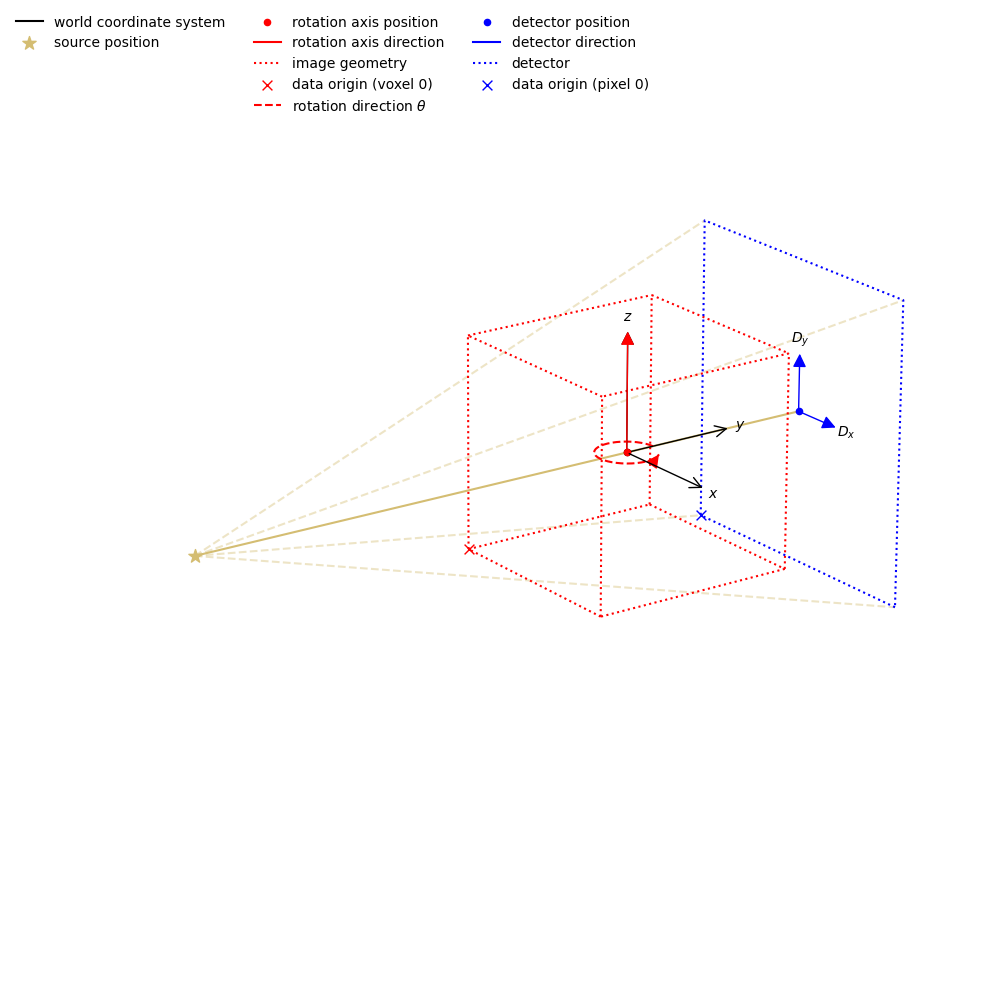

In [8]:
show_geometry(data.geometry);

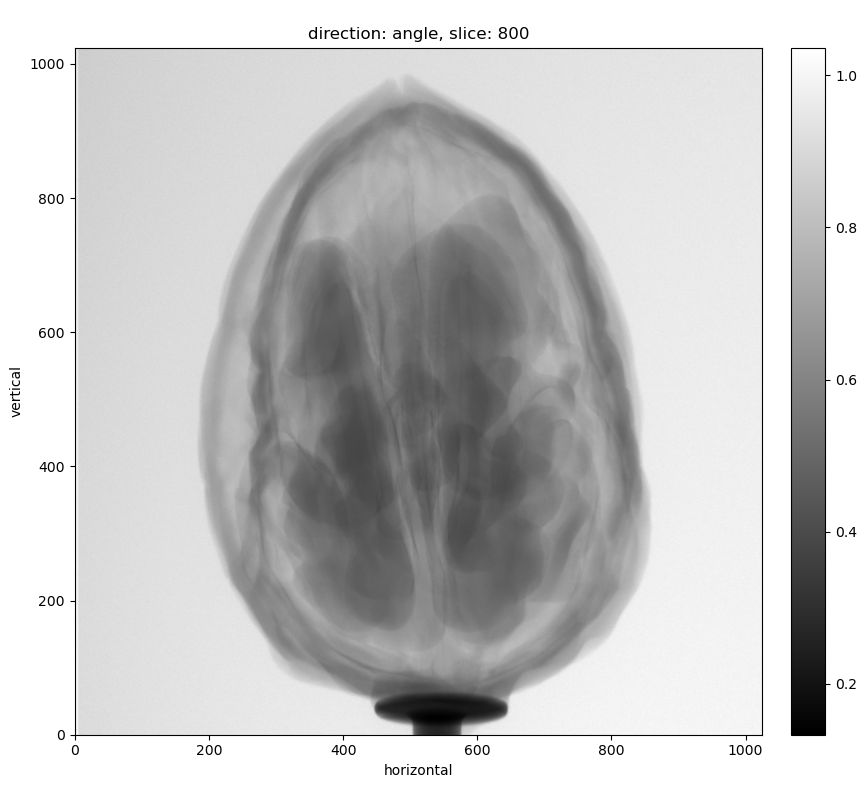

In [9]:
show2D(data, slice_list=('angle',800));

In [10]:
data = TransmissionAbsorptionConverter(accelerated=False)(data)

In [11]:
islicer(data)

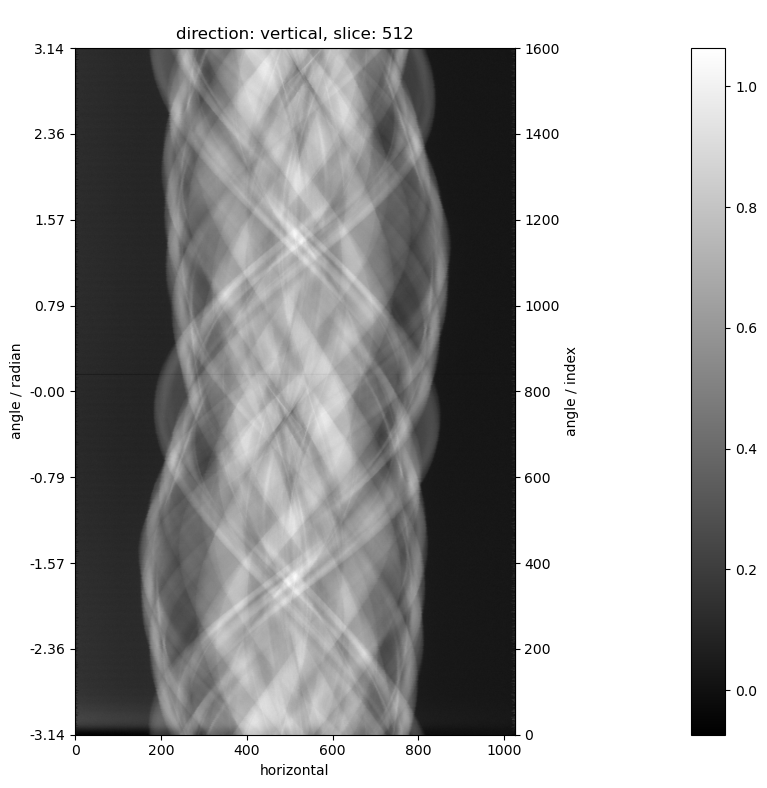

In [12]:
show2D(data, slice_list=('vertical', 512));

In [13]:
data.reorder(order='astra')

ig = data.geometry.get_ImageGeometry()
ag = data.geometry

A = ProjectionOperator(ig, ag, device = 'gpu')

In [15]:
def onenorm_cgls(initial, inner_iter, outer_iter, A, sino, alpha, er):

    """
    Function that minimises the cost function 

    J(u) = ||Ru - b||_2^2 + ||u||_1

    by minimising 

    J(u) = ||Ru - b||_2^2 + ||W_k u||_2^2

    via the BlockFramework and the cgls function from CIL. the matrix W_k is reweighted in each iteration
    with W_k = u_k**(-1/2)

    Input
        Initial:    initial guess for u (ImageData)
        inner_iter: maximum number of iterations for cgls (integer)
        outer_iter: maximum number of iterations to reweight W_k (integer)
        A:          operator R (ProjectionOperator)
        sino:       lhs of the data fidelity term, 'b' (ImageData)
        alpha:      regularisation parameter (float)
        er:         lower bound for values in W_k to be considered to reweight, 
                    low values will be set to zero (float)

    Output
        uk:         reconstructed image (ImageData)
    """

    uk = initial.copy()
    for k in range(outer_iter):

        print("Outer iteration:", k + 1)
        
        ## reweight the regularisation term ##
        weights = (uk.abs() + 1e-6) ** (-1/2)

        ## setting up minimisation functional in BlockFramework ##

        # set W
        w_operator = DiagonalOperator(weights)

        # create block operator
        operator_block = BlockOperator(A, np.sqrt(alpha)*w_operator)

        # create block data container
        zero_block = w_operator.range.allocate(0)
        data_block = BlockDataContainer(sino, zero_block)

        # solver inner minimization problem 
        #cgls = CGLS(initial=uk, operator=operator_block, data=data_block, update_objective_interval=1)

        # CGLS EarlyStopping terminates CG when ||..._k|| < epsilon*||..._0||
        #cgls.run(inner_iter, verbose=0, callbacks=[callbacks.ProgressCallback(), 
                                                   #callbacks.CGLSEarlyStopping(epsilon=1e-6)])
        #uk = cgls.solution

    return uk

In [16]:
onenorm_cgls(initial = ig.allocate(), inner_iter = 1, outer_iter = 1, A = A, sino = data, 
alpha = 1, er = 1)

: 

In [ ]:
fdk =  FDK(data, ig)
recon = fdk.run()

FDK recon

Input Data:
	angle: 1601
	vertical: 1024
	horizontal: 1024

Reconstruction Volume:
	vertical: 1024
	horizontal_y: 1024
	horizontal_x: 1024

Reconstruction Options:
	Backend: tigre
	Filter: ram-lak
	Filter cut-off frequency: 1.0
	FFT order: 11
	Filter_inplace: False

